In [2]:
#%% Bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, dendrogram


#%% Criando o DataFrame

dados = pd.DataFrame({
    'estudante': ['Ana', 'Bruno', 'Carla', 'Diego', 'Elisa'],
    'teoria': [8.5, 6.0, 9.0, 4.5, 7.0],
    'prática': [8.0, 5.5, 9.5, 5.0, 6.5],
    'projeto': [7.5, 6.5, 8.5, 4.0, 7.0]
})

dados

,estudante,teoria,prática,projeto
0,Ana,8.5,8.0,7.5
1,Bruno,6.0,5.5,6.5
2,Carla,9.0,9.5,8.5
3,Diego,4.5,5.0,4.0
4,Elisa,7.0,6.5,7.0


In [3]:
#%% Selecionando as variáveis para clusterização

dados_cluster = dados[['teoria', 'prática', 'projeto']]

dados_cluster

,teoria,prática,projeto
0,8.5,8.0,7.5
1,6.0,5.5,6.5
2,9.0,9.5,8.5
3,4.5,5.0,4.0
4,7.0,6.5,7.0


In [5]:
#%% Cluster Hierárquico - Average Linkage

cluster_avg = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='average'
)

indica_cluster_avg = cluster_avg.fit_predict(dados_cluster)

dados['cluster_average'] = indica_cluster_avg
dados['cluster_average'] = dados['cluster_average'].astype('category')

dados

,estudante,teoria,prática,projeto,cluster_average
0,Ana,8.5,8.0,7.5,0
1,Bruno,6.0,5.5,6.5,1
2,Carla,9.0,9.5,8.5,0
3,Diego,4.5,5.0,4.0,2
4,Elisa,7.0,6.5,7.0,1


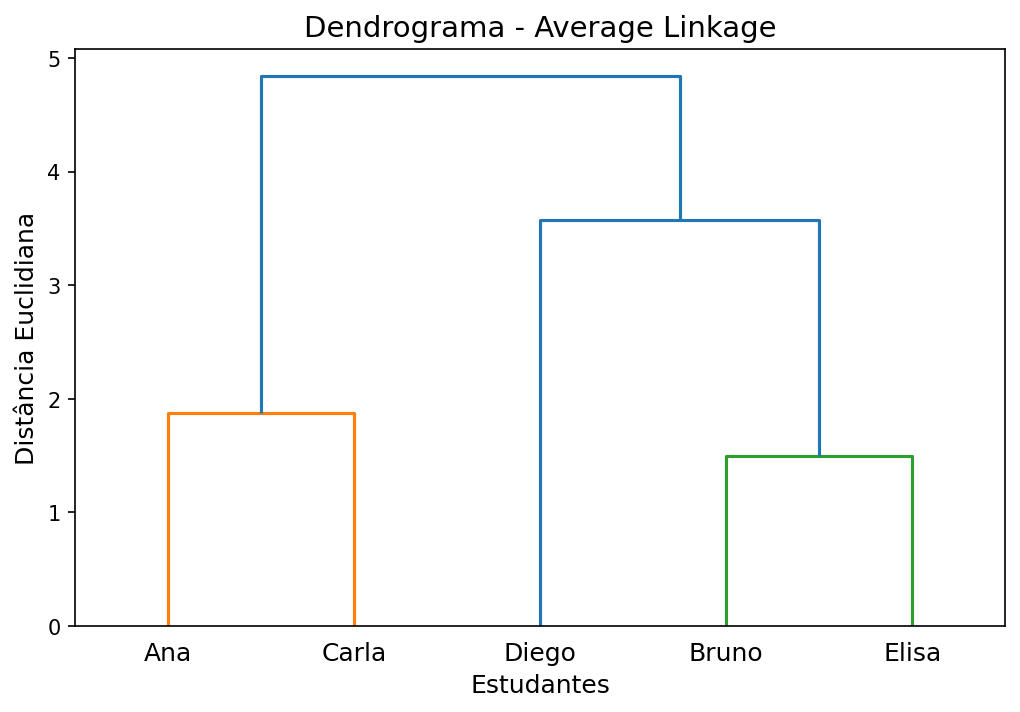

In [6]:
#%% Dendrograma - Average Linkage

Z_avg = linkage(dados_cluster, method='average', metric='euclidean')

plt.figure(figsize=(8, 5), dpi=150)

dendrogram_a = dendrogram(
    Z_avg,
    labels=dados['estudante'].values
)

plt.title('Dendrograma - Average Linkage', fontsize=14)
plt.xlabel('Estudantes', fontsize=12)
plt.ylabel('Distância Euclidiana', fontsize=12)
plt.show()

In [7]:
#%% Coeficientes do esquema hierárquico de aglomeração

coef_avg = [y[1] for y in dendrogram_a['dcoord']]

print(coef_avg)

[np.float64(1.8708286933869707), np.float64(1.5), np.float64(3.570670012110093), np.float64(4.840246695493289)]


In [9]:
#%% Cluster Não Hierárquico K-means

kmeans = KMeans(
    n_clusters=3,
    init='random',
    random_state=100,
    n_init=10
).fit(dados_cluster)

kmeans_clusters = kmeans.labels_

dados['cluster_kmeans'] = kmeans_clusters
dados['cluster_kmeans'] = dados['cluster_kmeans'].astype('category')

dados

C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,estudante,teoria,prática,projeto,cluster_average,cluster_kmeans
0,Ana,8.5,8.0,7.5,0,0
1,Bruno,6.0,5.5,6.5,1,2
2,Carla,9.0,9.5,8.5,0,0
3,Diego,4.5,5.0,4.0,2,1
4,Elisa,7.0,6.5,7.0,1,2


In [10]:
#%% Identificando as coordenadas dos centróides finais

cent_finais = pd.DataFrame(kmeans.cluster_centers_)

cent_finais.columns = dados_cluster.columns
cent_finais.index.name = 'cluster'

cent_finais

,teoria,prática,projeto
cluster,,,
0,8.75,8.75,8.00
1,4.50,5.00,4.00
2,6.50,6.00,6.75


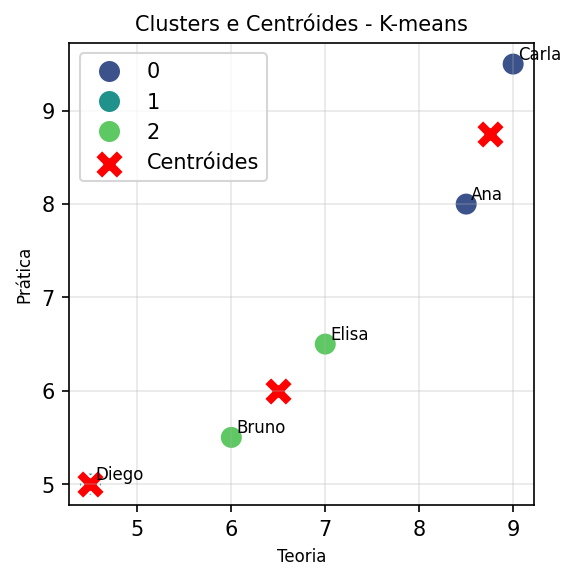

In [18]:
#%% Plotando as observações e seus centróides dos clusters

plt.figure(figsize=(4, 4), dpi=150)

sns.scatterplot(
    data=dados,
    x='teoria',
    y='prática',
    hue='cluster_kmeans',
    palette='viridis',
    s=120
)

sns.scatterplot(
    data=cent_finais,
    x='teoria',
    y='prática',
    color='red',
    label='Centróides',
    marker='X',
    s=200
)

# Adicionando o nome dos estudantes no gráfico
for i in range(dados.shape[0]):
    plt.text(
        dados['teoria'][i] + 0.05,
        dados['prática'][i] + 0.05,
        dados['estudante'][i],
        fontsize=8
    )

plt.title('Clusters e Centróides - K-means', fontsize=10)
plt.xlabel('Teoria', fontsize=8)
plt.ylabel('Prática', fontsize=8)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\MARELLO715\miniconda3\envs\scraping_h

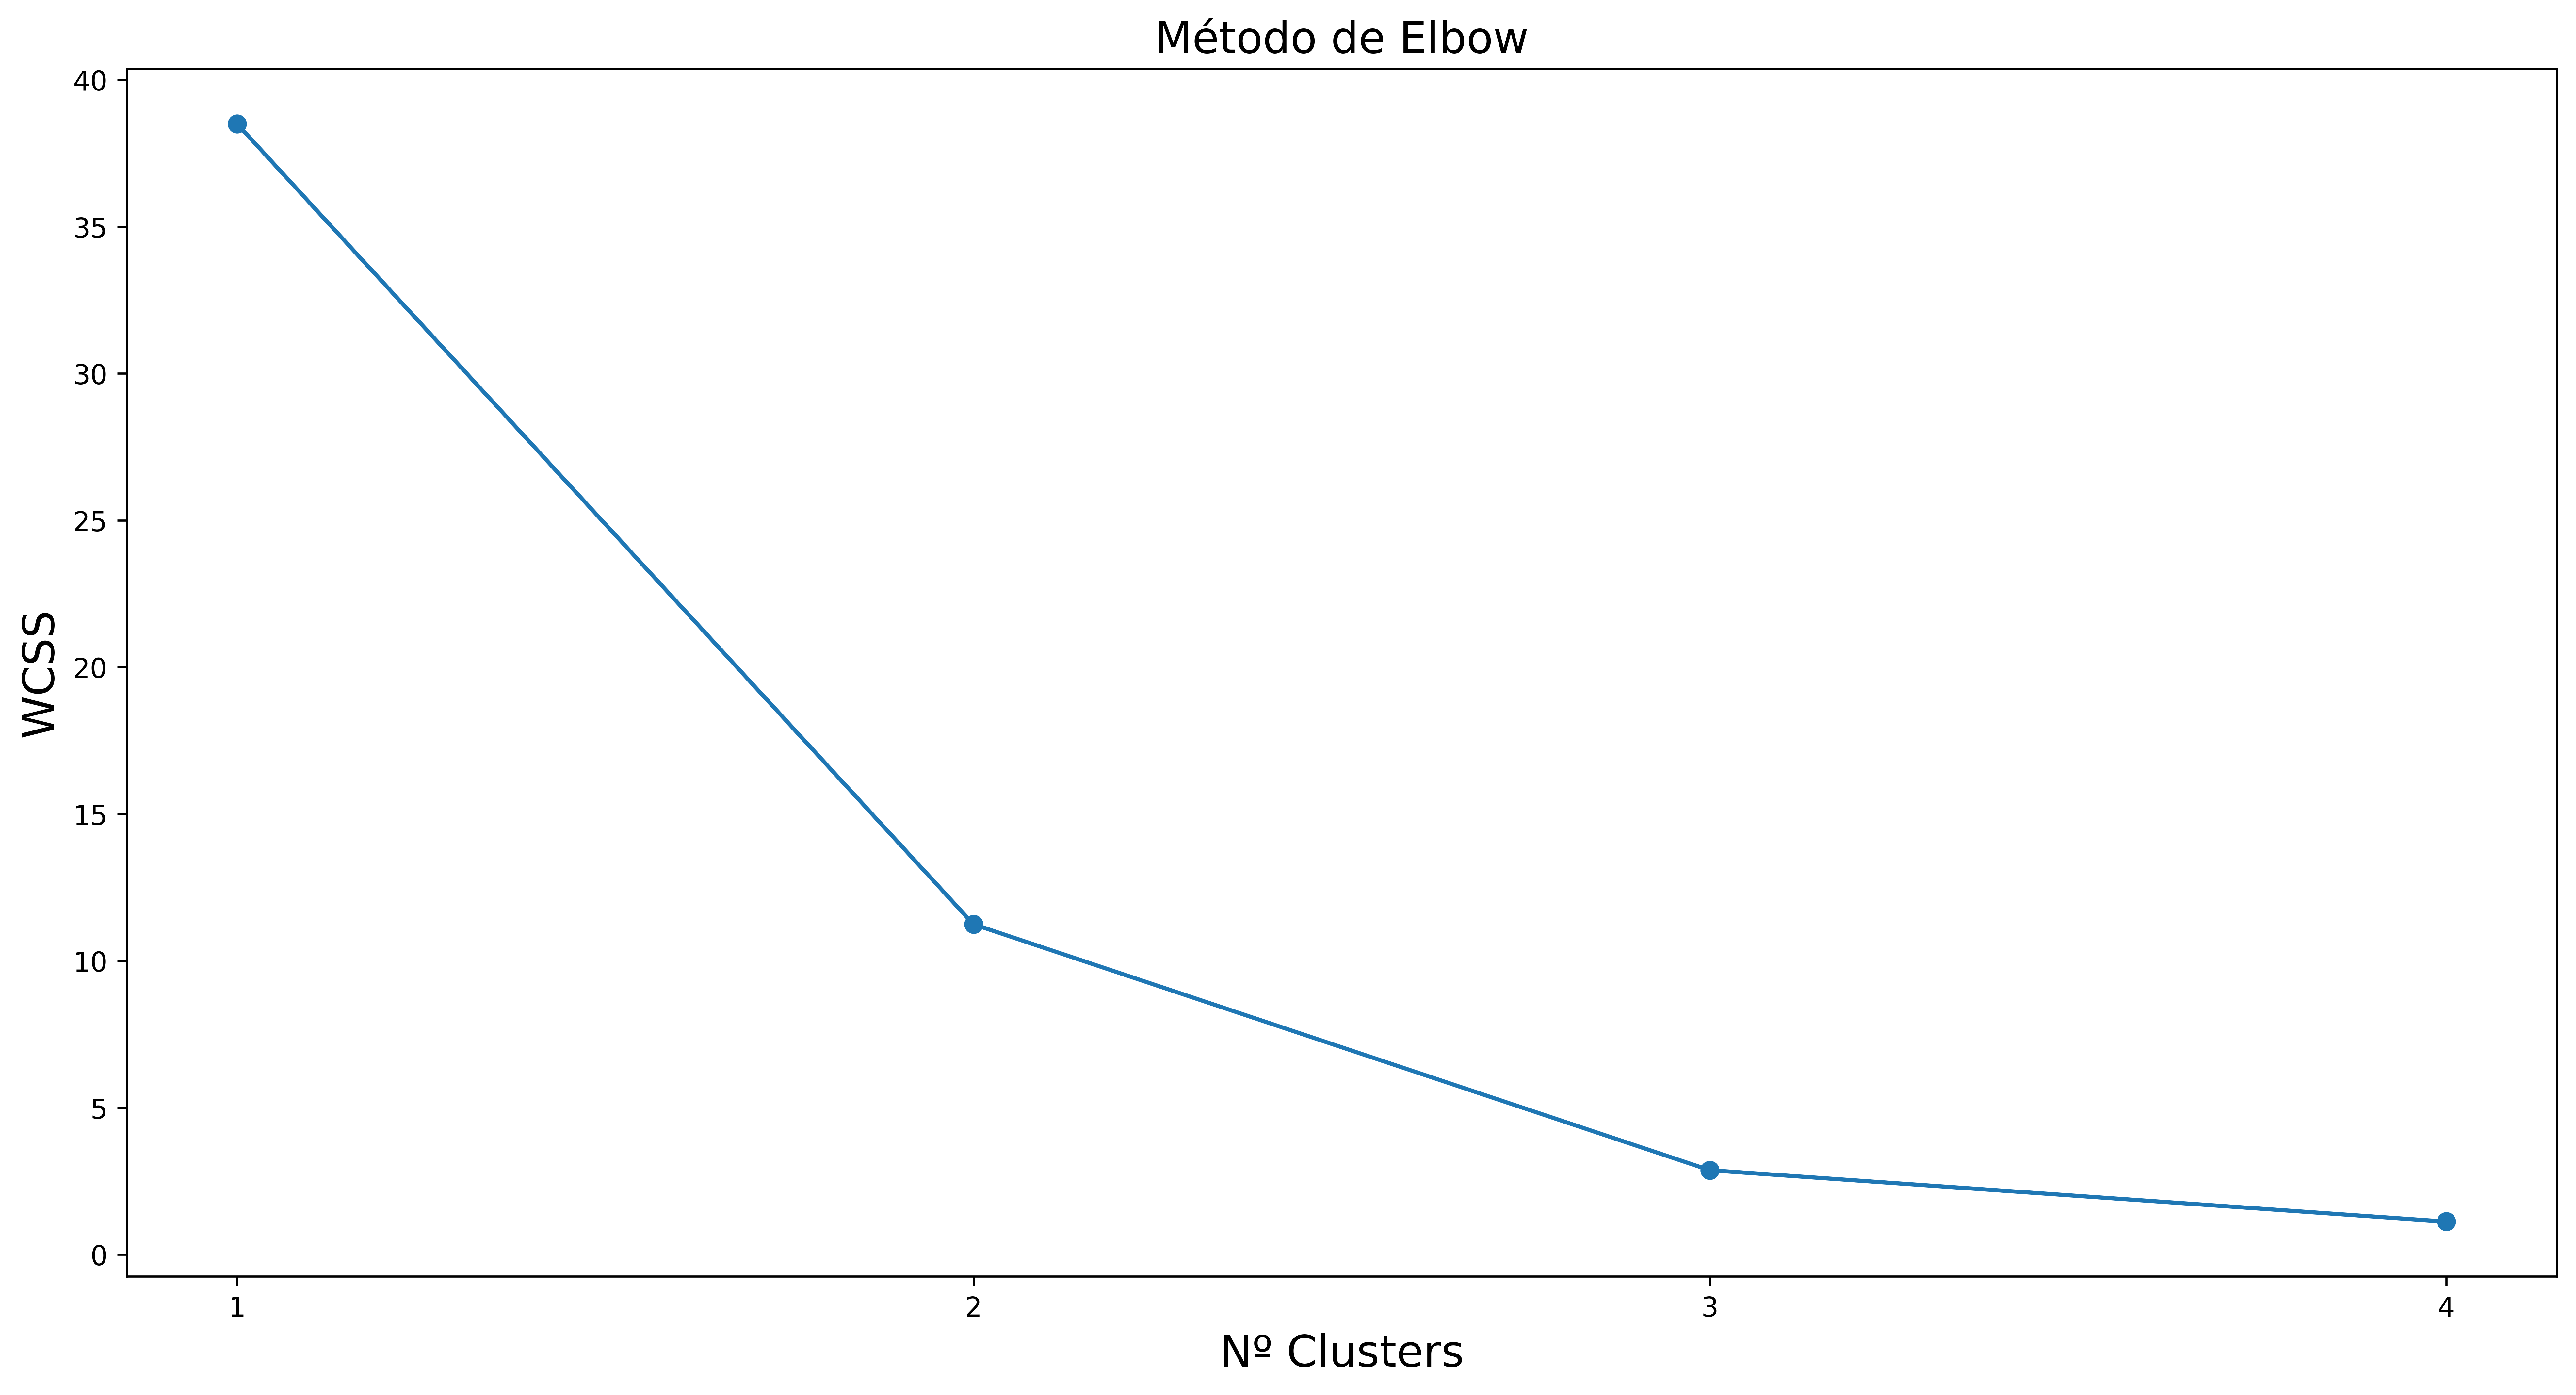

In [19]:
#%% Identificação da quantidade de clusters

# Método Elbow para identificação do nº de clusters
## Elaborado com base na "WCSS": distância das observações para o centroide de seu cluster
## Quanto mais próximas do centroide, menores as distâncias internas
## Normalmente, busca-se o "cotovelo", ou seja, o ponto onde a curva "dobra"

elbow = []
K = range(1,5) # ponto de parada pode ser parametrizado manualmente
for k in K:
    kmeanElbow = KMeans(n_clusters=k, init='random', random_state=100).fit(dados_cluster)
    elbow.append(kmeanElbow.inertia_)
    
plt.figure(figsize=(16,8), dpi=600)
plt.plot(K, elbow, marker='o')
plt.xlabel('Nº Clusters', fontsize=16)
plt.xticks(range(1,5)) # ajustar de acordo com o range de K definido acima
plt.ylabel('WCSS', fontsize=16)
plt.title('Método de Elbow', fontsize=16)
plt.show()

C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\MARELLO715\miniconda3\envs\scraping_hospitais\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


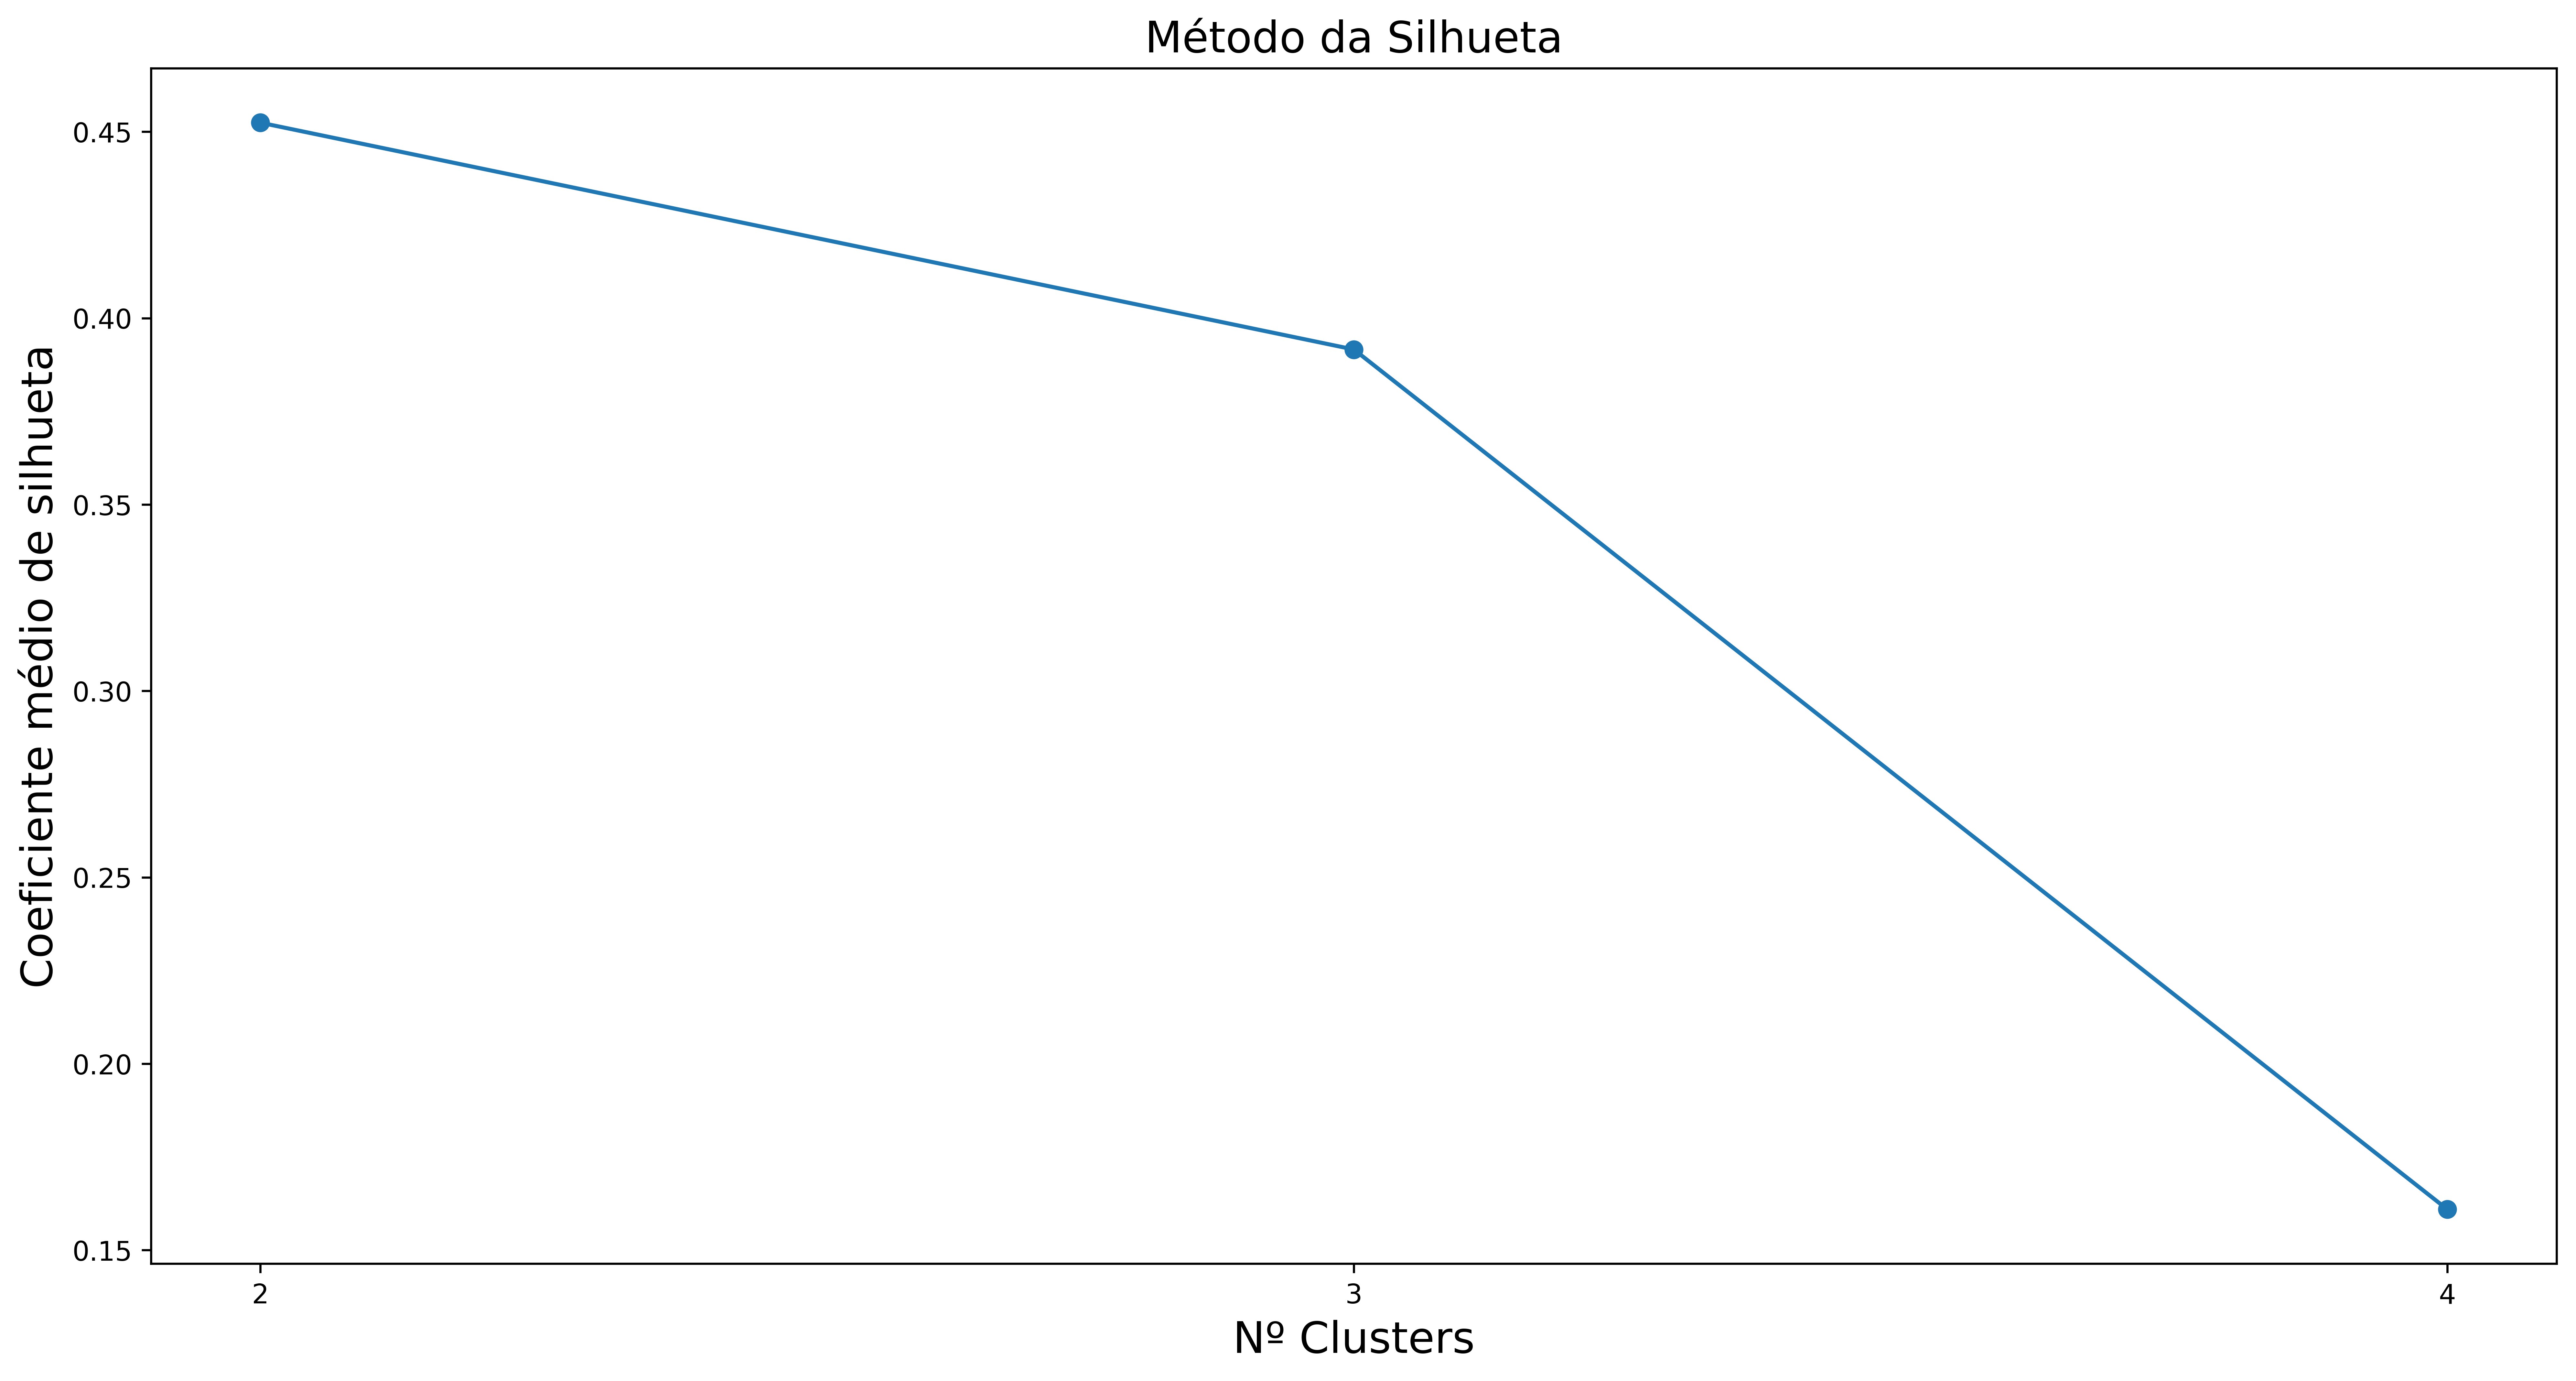

In [20]:
#%% Método da Silhueta

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

silhueta = []

K = range(2, 5)  # começa em 2, pois silhueta não existe para K = 1

for k in K:
    kmeans_sil = KMeans(
        n_clusters=k,
        init='random',
        random_state=100,
        n_init=10
    ).fit(dados_cluster)
    
    labels = kmeans_sil.labels_
    
    score = silhouette_score(dados_cluster, labels)
    silhueta.append(score)

#%% Plotando o gráfico da silhueta

plt.figure(figsize=(16, 8), dpi=600)

plt.plot(K, silhueta, marker='o')

plt.xlabel('Nº Clusters', fontsize=16)
plt.xticks(range(2, 5))
plt.ylabel('Coeficiente médio de silhueta', fontsize=16)
plt.title('Método da Silhueta', fontsize=16)

plt.show()

In [21]:
#%% Análise de variância de um fator (ANOVA)

# Caso ainda não tenha instalado:
# !pip install pingouin

import pingouin as pg

# Interpretação do output:
#
# cluster_kmeans MS: indica a variabilidade entre os clusters
# Within MS: indica a variabilidade dentro dos clusters
# F: estatística de teste = variabilidade entre clusters / variabilidade dentro dos clusters
# p-unc: p-valor da estatística F
#
# Se p-valor < 0.05:
# pelo menos um cluster apresenta média estatisticamente diferente dos demais
#
# A variável mais discriminante tende a apresentar maior estatística F,
# desde que o resultado seja estatisticamente significativo.

In [23]:
#%% ANOVA - Teoria

anova_teoria = pg.anova(
    dv='teoria',
    between='cluster_kmeans',
    data=dados,
    detailed=True
).T

anova_teoria

,0,1
Source,cluster_kmeans,Within
SS,12.875,0.625
DF,2,2
MS,6.4375,0.3125
F,20.6,NaN
p_unc,0.046296,NaN
np2,0.953704,NaN


In [24]:
#%% ANOVA - Prática

anova_pratica = pg.anova(
    dv='prática',
    between='cluster_kmeans',
    data=dados,
    detailed=True
).T

anova_pratica

,0,1
Source,cluster_kmeans,Within
SS,12.075,1.625
DF,2,2
MS,6.0375,0.8125
F,7.430769,NaN
p_unc,0.118613,NaN
np2,0.881387,NaN


In [25]:
#%% ANOVA - Projeto

anova_projeto = pg.anova(
    dv='projeto',
    between='cluster_kmeans',
    data=dados,
    detailed=True
).T

anova_projeto

,0,1
Source,cluster_kmeans,Within
SS,10.675,0.625
DF,2,2
MS,5.3375,0.3125
F,17.08,NaN
p_unc,0.05531,NaN
np2,0.94469,NaN


In [30]:
resultado = pg.anova(
    dv='teoria',
    between='cluster_kmeans',
    data=dados,
    detailed=True
)

print(resultado)
print(resultado.columns)

           Source      SS  DF      MS     F     p_unc       np2
0  cluster_kmeans  12.875   2  6.4375  20.6  0.046296  0.953704
1          Within   0.625   2  0.3125   NaN       NaN       NaN
Index(['Source', 'SS', 'DF', 'MS', 'F', 'p_unc', 'np2'], dtype='object')


In [32]:
#%% Comparando as variáveis pela estatística F

variaveis = ['teoria', 'prática', 'projeto']

resultados_anova = []

for var in variaveis:
    resultado = pg.anova(
        dv=var,
        between='cluster_kmeans',
        data=dados,
        detailed=True
    )
    
    resultados_anova.append({
        'variavel': var,
        'F': resultado.loc[0, 'F'],
        'p_valor': resultado.loc[0, 'p_unc'],
        'significativo_5%': resultado.loc[0, 'p_unc'] < 0.05
    })

df_anova = pd.DataFrame(resultados_anova)

df_anova = df_anova.sort_values(by='F', ascending=False)

df_anova

,variavel,F,p_valor,significativo_5%
0,teoria,20.600000,0.046296,True
2,projeto,17.080000,0.055310,False
1,prática,7.430769,0.118613,False


In [33]:
#%% Identificando a variável mais discriminante

variavel_mais_discriminante = df_anova.iloc[0]['variavel']
maior_f = df_anova.iloc[0]['F']
p_valor = df_anova.iloc[0]['p_valor']

print(f"Variável mais discriminante: {variavel_mais_discriminante}")
print(f"Estatística F: {maior_f:.4f}")
print(f"p-valor: {p_valor:.4f}")

Variável mais discriminante: teoria
Estatística F: 20.6000
p-valor: 0.0463
